# <font color="darkblue"> Prática 01: Perceptron Learning Algorithm (PLA) </font>

**Objetivos:**
* Entender o funcionamento do PLA e dos componentes de aprendizagem.
* Fixar o conceito de aprendizagem.

**Descrição:**

Crie uma dataset $D$ com 1000 pontos e uma função alvo $f$ para compreender o funcionamento do PLA. Para visualizar os passos do algoritmo, considere $d=2$ e assuma $X=[-1,1]\times[-1,1]$, em que $x\in X$ é escolhido com probabilidade uniforme. Escolha uma reta como função alvo, em que um lado da reta seja mapeado para $+1$ e o outro para $-1$. Gere então pontos aleatórios $x_i$ e obtenha sua classificação $y_i$ a partir da função alvo. Divida os dados em um grupo de treinamento e outro de teste.

Após a preparação dos dados, crie uma função $PLA()$ que inicia com os pesos todos iguais a zero e, a cada iteração, deixe o algoritmo escolher aleatoriamente um dos pontos com classificação incorreta até que ele convirja. Rode o PLA sobre subamostras com $N=10$ e $N=100$, teste a hipótese solução a partir de pontos ainda não vistos (conjunto de teste) e responda a seguinte questão:

- Qual o percentual de pontos classificados corretamente para cada hipótese solução nos conjuntos de treinamento e teste?

# <font color="darkblue"> Solução </font>

### Preparação dos dados

O objetivo da preparação dos dados é a criação da função alvo e do dataset conforme a descrição do problema.

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output

# Fixar semente para reprodutibilidade
np.random.seed(42)
random.seed(42)

# -------------------------------------------------------
# 1. Criar a função alvo f a partir de dois pontos aleatórios
# -------------------------------------------------------
# Gera dois pontos aleatórios em [-1, 1] x [-1, 1]
p1 = [random.uniform(-1, 1), random.uniform(-1, 1)]
p2 = [random.uniform(-1, 1), random.uniform(-1, 1)]

# Coeficiente angular (m) e linear (b) da reta f(x) = m*x + b
m = (p2[1] - p1[1]) / (p2[0] - p1[0])   # Δy / Δx
b = p1[1] - m * p1[0]                    # b = y1 - m*x1

print(f"Função alvo: f(x) = {m:.4f}x + {b:.4f}")
print(f"Pontos usados: p1={p1}, p2={p2}")

# -------------------------------------------------------
# 2. Gerar 1000 pontos aleatórios em [-1, 1] x [-1, 1]
# -------------------------------------------------------
N_total = 1000
X = [[random.uniform(-1, 1), random.uniform(-1, 1)] for _ in range(N_total)]

# -------------------------------------------------------
# 3. Classificar cada ponto de acordo com a função alvo
#    sign(y_i - (m * x_i + b)) => acima da reta: +1, abaixo: -1
# -------------------------------------------------------
y = [int(np.sign(X[i][1] - (m * X[i][0] + b))) for i in range(N_total)]

# Tratar pontos sobre a reta (sign = 0) como -1
y = [yi if yi != 0 else -1 for yi in y]

print(f"\nTotal de pontos: {N_total}")
print(f"Classe +1: {y.count(1)} pontos")
print(f"Classe -1: {y.count(-1)} pontos")

Função alvo: f(x) = -0.5439x + -0.7983
Pontos usados: p1=[0.2788535969157675, -0.9499784895546661], p2=[-0.4499413632617615, -0.5535785237023545]

Total de pontos: 1000
Classe +1: 877 pontos
Classe -1: 123 pontos


### Visualizando o dataset

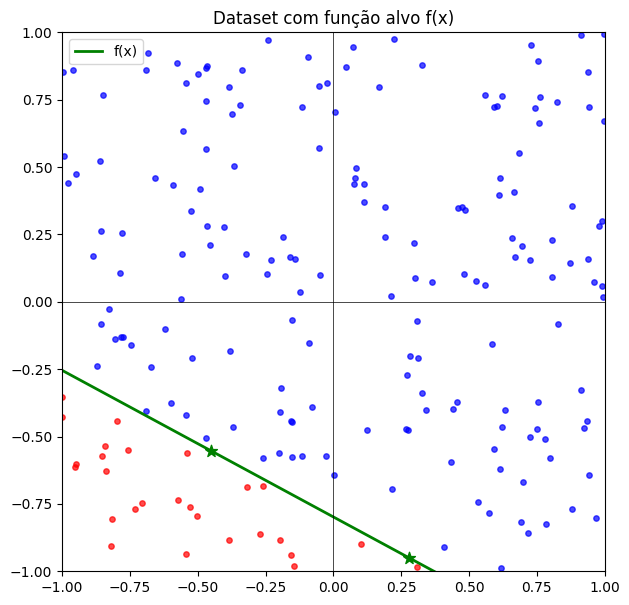

In [79]:
def show_dataset(X, y, p1, p2, m, b):
    """
    Exibe uma amostra do dataset.

    Parâmetros:
    - X (list[]): Matriz 1000x2 com os dados da amostra.
    - y (list): Classificação dos pontos.
    - p1 (list): Ponto p1 usado para criar a função alvo.
    - p2 (list): Ponto p2 usado para criar a função alvo.
    - m (float): Coeficiente angular da função alvo.
    - b (float): Coeficiente linear da função alvo.
    """
    plt.figure(figsize=(7, 7))
    line = np.linspace(-1, 1, 1000)
    plt.plot(line, m * line + b, label="f(x)", c="green", linewidth=2)

    # Pontos usados na criação da reta
    plt.scatter(p1[0], p1[1], c='green', zorder=5, s=80, marker='*')
    plt.scatter(p2[0], p2[1], c='green', zorder=5, s=80, marker='*')

    for i in range(len(X[:200])):
        if y[i] == 1:
            plt.scatter(X[i][0], X[i][1], c='blue', s=15, alpha=0.7)
        else:
            plt.scatter(X[i][0], X[i][1], c='red', s=15, alpha=0.7)

    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title("Dataset com função alvo f(x)")
    plt.legend()
    plt.show()

show_dataset(X, y, p1, p2, m, b)

### Função para construir lista de pontos classificados incorretamente

In [80]:
def constroiListaPCI(X, y, w):
    """
    Constrói a lista de pontos classificados incorretamente.

    O perceptron classifica um ponto x como:
        h(x) = sign(w[0] + w[1]*x[0] + w[2]*x[1])
    onde w[0] é o bias (w0), w[1] é o peso para x1, w[2] para x2.

    Um ponto está incorreto quando h(x_i) != y_i.

    Parâmetros:
    - X (list[]): Dados da amostra.
    - y (list): Classificações corretas.
    - w (list): Vetor de pesos [w0, w1, w2].

    Retorno:
    - l (list): Lista de pontos classificados incorretamente.
    - new_y (list): Classificações corretas dos pontos em l.
    """
    l = []
    new_y = []

    for i in range(len(X)):
        # Sinal da combinação linear: w0*1 + w1*x1 + w2*x2
        activation = w[0] + w[1] * X[i][0] + w[2] * X[i][1]
        predicao = int(np.sign(activation))

        # Tratar predição 0 como -1
        if predicao == 0:
            predicao = -1

        # Se classificou incorretamente, adiciona à lista
        if predicao != y[i]:
            l.append(X[i])
            new_y.append(y[i])

    return l, new_y

### Função para visualização dos passos do PLA

In [81]:
%matplotlib inline

def plot_grafico(X, y, w, f):
    """
    Visualiza os passos do PLA: mostra os pontos, a função alvo (verde)
    e a hipótese atual do perceptron (laranja).

    Parâmetros:
    - X (list[]): Dados da amostra.
    - y (list): Classificações corretas.
    - w (list): Vetor de pesos [w0, w1, w2].
    - f (list): [m, b] da função alvo.
    """
    nPontos = len(X)

    ax = plt.gca()
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['right'].set_color('none')

    plt.axis([-1, 1, -1, 1])

    x_plt = [X[i][0] for i in range(nPontos)]
    y_plt = [X[i][1] for i in range(nPontos)]

    for i in range(nPontos):
        if y[i] == 1:
            plt.scatter(x_plt[i], y_plt[i], s=10, c='blue')
        else:
            plt.scatter(x_plt[i], y_plt[i], s=10, c='red')

    x = np.linspace(-1, 1, 1000)
    plt.plot(x, f[0] * x + f[1], c='green', label='f(x) alvo')

    # Reta do perceptron: w0 + w1*x + w2*y = 0  =>  y = (-w0 - w1*x) / w2
    if w[2] != 0:
        plt.plot(x, (-w[0] - w[1] * x) / w[2], c='orange', label='h(x) perceptron')

    clear_output(wait=True)
    plt.show(block=False)
    plt.pause(0.01)

### Algoritmo PLA

```
Algoritmo PLA(X):
    w = [0, 0, 0]
    listaPCI = X            # começa com todos os pontos (pesos zero → tudo errado)
    enquanto len(listaPCI) > 0:
        escolhe aleatoriamente x_i em listaPCI
        w = w + y_i * x_i   # atualiza pesos
        listaPCI = constroiListaPCI(X, w)
    retorna w
```

In [82]:
def PLA(X, y, f, visualizar=True):
    """
    Algoritmo de Aprendizagem do Perceptron (PLA).

    O vetor de pesos w = [w0, w1, w2] representa:
        h(x) = sign(w0*1 + w1*x1 + w2*x2)
    onde w0 é o bias (threshold). Para incorporá-lo, o ponto x é
    representado como [1, x1, x2], então:
        w = w + y_i * [1, x_i[0], x_i[1]]

    Parâmetros:
    - X (list[]): Dados de treinamento.
    - y (list): Classificações corretas.
    - f (list): [m, b] da função alvo (para plotagem).
    - visualizar (bool): Se True, plota a cada iteração.

    Retorno:
    - it (int): Número de iterações para convergir.
    - w (list): Pesos finais [w0, w1, w2].
    """
    # Inicializa todos os pesos com zero
    w = [0.0, 0.0, 0.0]
    it = 0

    # Constrói lista inicial de pontos classificados incorretamente
    listaPCI, listaPCI_y = constroiListaPCI(X, y, w)

    while len(listaPCI) > 0:
        it += 1

        # Escolhe aleatoriamente um ponto mal classificado
        idx = random.randint(0, len(listaPCI) - 1)
        xi = listaPCI[idx]      # ponto escolhido
        yi = listaPCI_y[idx]    # sua classificação correta

        # Atualiza o vetor de pesos: w = w + yi * [1, xi[0], xi[1]]
        w[0] = w[0] + yi * 1        # bias
        w[1] = w[1] + yi * xi[0]    # peso para x1
        w[2] = w[2] + yi * xi[1]    # peso para x2

        # Visualiza o passo atual (opcional)
        if visualizar:
            plot_grafico(X, y, w, f)

        # Reconstrói a lista de pontos classificados incorretamente
        listaPCI, listaPCI_y = constroiListaPCI(X, y, w)

    return it, w

### Função para calcular acurácia

In [83]:
def acuracia(X, y, w):
    """
    Calcula o percentual de pontos classificados corretamente pelo perceptron.

    Parâmetros:
    - X (list[]): Dados.
    - y (list): Classificações corretas.
    - w (list): Pesos do perceptron [w0, w1, w2].

    Retorno:
    - (float): Percentual de acertos (0 a 100).
    """
    acertos = 0
    for i in range(len(X)):
        activation = w[0] + w[1] * X[i][0] + w[2] * X[i][1]
        predicao = int(np.sign(activation))
        if predicao == 0:
            predicao = -1
        if predicao == y[i]:
            acertos += 1
    return (acertos / len(X)) * 100

### Treinamento e avaliação com N=10 e N=100

Divide o dataset em:
- Subamostra de treinamento com N=10
- Subamostra de treinamento com N=100
- Conjunto de teste com os 900 pontos restantes (não vistos durante o treino com N=100)

In [84]:
# Embaralha os índices para divisão aleatória
indices = list(range(N_total))
random.shuffle(indices)

# Divisão dos dados
idx_train_10  = indices[:10]     # 10 pontos para treino (N=10)
idx_train_100 = indices[:100]    # 100 pontos para treino (N=100)
idx_test      = indices[100:]    # 900 pontos restantes para teste

X_train_10  = [X[i] for i in idx_train_10]
y_train_10  = [y[i] for i in idx_train_10]

X_train_100 = [X[i] for i in idx_train_100]
y_train_100 = [y[i] for i in idx_train_100]

X_test = [X[i] for i in idx_test]
y_test = [y[i] for i in idx_test]

f = [m, b]  # parâmetros da função alvo para plotagem

print(f"Treinamento N=10:  {len(X_train_10)} pontos")
print(f"Treinamento N=100: {len(X_train_100)} pontos")
print(f"Teste:             {len(X_test)} pontos")

Treinamento N=10:  10 pontos
Treinamento N=100: 100 pontos
Teste:             900 pontos


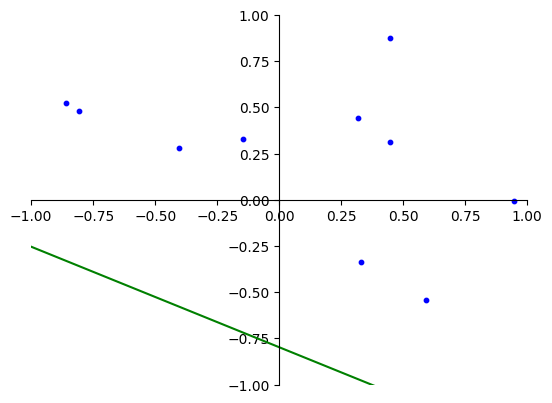

Iterações até convergência: 1
Pesos finais: w0=1.00, w1=-0.15, w2=0.33
Acurácia no treino  (N=10):  100.00%
Acurácia no teste   (N=10):  87.78%


In [85]:
# -------------------------------------------------------
# Treinamento com N=10
# -------------------------------------------------------
print("="*50)
print("Treinando PLA com N=10...")
it_10, w_10 = PLA(X_train_10, y_train_10, f, visualizar=True)

acc_train_10 = acuracia(X_train_10, y_train_10, w_10)
acc_test_10  = acuracia(X_test, y_test, w_10)

print(f"Iterações até convergência: {it_10}")
print(f"Pesos finais: w0={w_10[0]:.2f}, w1={w_10[1]:.2f}, w2={w_10[2]:.2f}")
print(f"Acurácia no treino  (N=10):  {acc_train_10:.2f}%")
print(f"Acurácia no teste   (N=10):  {acc_test_10:.2f}%")

Treinando PLA com N=100...
Iterações até convergência: 68
Pesos finais: w0=4.00, w1=3.09, w2=4.80
Acurácia no treino  (N=100): 100.00%
Acurácia no teste   (N=100): 99.11%


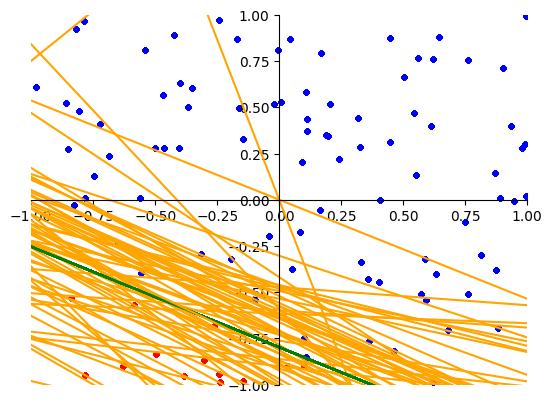

In [77]:
# -------------------------------------------------------
# Treinamento com N=100
# -------------------------------------------------------
print("="*50)
print("Treinando PLA com N=100...")
it_100, w_100 = PLA(X_train_100, y_train_100, f, visualizar=True)

acc_train_100 = acuracia(X_train_100, y_train_100, w_100)
acc_test_100  = acuracia(X_test, y_test, w_100)

print(f"Iterações até convergência: {it_100}")
print(f"Pesos finais: w0={w_100[0]:.2f}, w1={w_100[1]:.2f}, w2={w_100[2]:.2f}")
print(f"Acurácia no treino  (N=100): {acc_train_100:.2f}%")
print(f"Acurácia no teste   (N=100): {acc_test_100:.2f}%")

### Visualização final: comparação das hipóteses

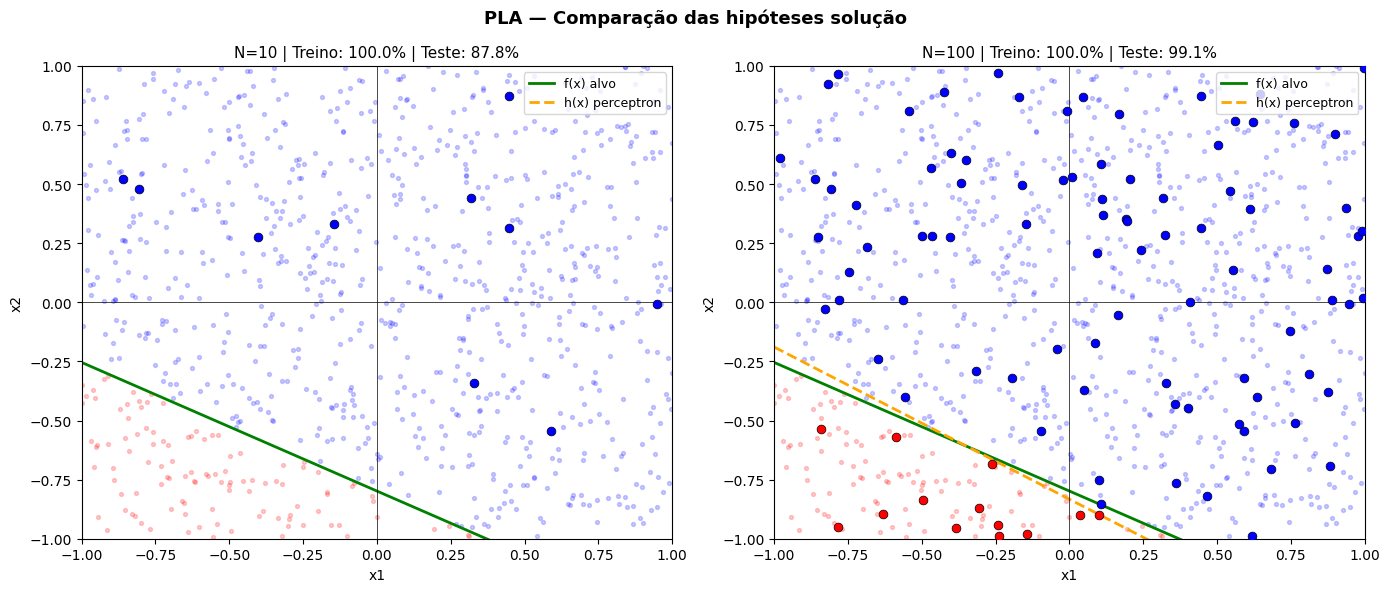

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x_line = np.linspace(-1, 1, 1000)

titulos = [f"N=10 | Treino: {acc_train_10:.1f}% | Teste: {acc_test_10:.1f}%",
           f"N=100 | Treino: {acc_train_100:.1f}% | Teste: {acc_test_100:.1f}%"]
pesos   = [w_10, w_100]
treinamentos = [X_train_10, X_train_100]
labels_treino = [y_train_10, y_train_100]

for ax, w, X_tr, y_tr, titulo in zip(axes, pesos, treinamentos, labels_treino, titulos):
    # Pontos de treino
    for i in range(len(X_tr)):
        cor = 'blue' if y_tr[i] == 1 else 'red'
        ax.scatter(X_tr[i][0], X_tr[i][1], c=cor, s=40, zorder=3, edgecolors='black', linewidths=0.5)

    # Pontos de teste (mais transparentes)
    for i in range(len(X_test)):
        cor = 'blue' if y_test[i] == 1 else 'red'
        ax.scatter(X_test[i][0], X_test[i][1], c=cor, s=8, alpha=0.2, zorder=1)

    # Função alvo
    ax.plot(x_line, m * x_line + b, c='green', linewidth=2, label='f(x) alvo')

    # Hipótese do perceptron
    if w[2] != 0:
        ax.plot(x_line, (-w[0] - w[1] * x_line) / w[2], c='orange',
                linewidth=2, linestyle='--', label='h(x) perceptron')

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.suptitle("PLA — Comparação das hipóteses solução", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Resumo dos resultados

In [87]:
print("="*55)
print(f"{'':5} {'N=10':>15} {'N=100':>15}")
print("-"*55)
print(f"{'Iterações':25} {it_10:>10}     {it_100:>10}")
print(f"{'Acurácia Treino (%)':25} {acc_train_10:>10.2f}     {acc_train_100:>10.2f}")
print(f"{'Acurácia Teste  (%)':25} {acc_test_10:>10.2f}     {acc_test_100:>10.2f}")
print("="*55)
print()
print("Conclusão:")
print(f"- Com N=10, o PLA converge em {it_10} iterações mas pode ter acurácia")
print(f"  menor no teste ({acc_test_10:.1f}%), pois viu poucos pontos.")
print(f"- Com N=100, o PLA converge em {it_100} iterações e tende a generalizar")
print(f"  melhor ({acc_test_100:.1f}% no teste) por ter aprendido com mais dados.")

                 N=10           N=100
-------------------------------------------------------
Iterações                          1             68
Acurácia Treino (%)           100.00         100.00
Acurácia Teste  (%)            87.78          99.11

Conclusão:
- Com N=10, o PLA converge em 1 iterações mas pode ter acurácia
  menor no teste (87.8%), pois viu poucos pontos.
- Com N=100, o PLA converge em 68 iterações e tende a generalizar
  melhor (99.1% no teste) por ter aprendido com mais dados.
